# ***PITP – Batch 5, Phase 2 = Final Project***

In [ ]:
import pandas as pd # pandas is library

In [ ]:
df = pd.read_csv('/content/diabetes_prediction_dataset.csv.zip')  # Load the dataset from the specified file path into a pandas DataFrame

# ***Data Preprocessing:***

In [ ]:
df.head() # Display the first five rows

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.shape # To know number of raws and column

(100000, 9)

***Checking Null Values***

In [ ]:
df.isnull().sum() # Checking for the null values

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


***Encoding Categorical Variables***

*   converting variable categories into numbers



In [ ]:
df = pd.get_dummies(df, columns=['gender'], prefix='gender',dtype = int) # This creates 'gender_Female', 'gender_Male' seperate column

print(df.head())

    age  hypertension  heart_disease smoking_history    bmi  HbA1c_level  \
0  80.0             0              1           never  25.19          6.6   
1  54.0             0              0         No Info  27.32          6.6   
2  28.0             0              0           never  27.32          5.7   
3  36.0             0              0         current  23.45          5.0   
4  76.0             1              1         current  20.14          4.8   

   blood_glucose_level  diabetes  gender_Female  gender_Male  gender_Other  
0                  140         0              1            0             0  
1                   80         0              1            0             0  
2                  158         0              0            1             0  
3                  155         0              1            0             0  
4                  155         0              0            1             0  


In [ ]:
df.head()

,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other
0,80.0,0,1,never,25.19,6.6,140,0,1,0,0
1,54.0,0,0,No Info,27.32,6.6,80,0,1,0,0
2,28.0,0,0,never,27.32,5.7,158,0,0,1,0
3,36.0,0,0,current,23.45,5.0,155,0,1,0,0
4,76.0,1,1,current,20.14,4.8,155,0,0,1,0


In [ ]:
# To converts each text category into a simple number (0, 1, 2, etc.)
smoking_map = {
    'never': 0,
    'No Info': 1,
    'current': 2,
    'former': 3,
    'ever': 4,
    'not current': 5
}

# Apply the map to the column
df['smoking_history_encoded'] = df['smoking_history'].map(smoking_map)

print(df[['smoking_history', 'smoking_history_encoded']].head())

  smoking_history  smoking_history_encoded
0           never                        0
1         No Info                        1
2           never                        0
3         current                        2
4         current                        2


***Deleting Column***

In [ ]:
df.drop('smoking_history', axis=1, inplace=True) # To delete unwanted column
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_encoded
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,1
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,2
4,76.0,1,1,20.14,4.8,155,0,0,1,0,2


 ***Normalize Or Standardize Numerical Features***

In [ ]:
# Outlier Treatment


# BMI — Winsorize (cap at 1st and 99th percentile)
# Extreme BMI values (10-14, 60-95) exist but keep all rows.
lower_bmi = df['bmi'].quantile(0.01)
upper_bmi = df['bmi'].quantile(0.99)
df['bmi'] = df['bmi'].clip(lower_bmi, upper_bmi)

print(f"BMI clipped to [{lower_bmi:.2f}, {upper_bmi:.2f}]")

print("Outlier treatment complete. Shape:", df.shape)

BMI clipped to [14.60, 48.79]
Outlier treatment complete. Shape: (100000, 9)


In [ ]:
from sklearn.preprocessing import StandardScaler # Standardization makes the Mean = 0 and the Standard Deviation = 1 for every column

# Initialize the scaler
scaler = StandardScaler()

num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

df[num_cols] = scaler.fit_transform(df[num_cols]) # It calculates the mean and the spread (standard deviation) of each column.

print("Standardized Data:")
print(df[num_cols].head())

Standardized Data:
        age       bmi  HbA1c_level  blood_glucose_level
0  1.692704 -0.321056     1.001706             0.047704
1  0.538006 -0.000116     1.001706            -1.426210
2 -0.616691 -0.000116     0.161108             0.489878
3 -0.261399 -0.583232    -0.492690             0.416183
4  1.515058 -1.081970    -0.679490             0.416183


In [ ]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_encoded
0,1.692704,0,1,-0.321056,1.001706,0.047704,0,1,0,0,0
1,0.538006,0,0,-0.000116,1.001706,-1.426210,0,1,0,0,1
2,-0.616691,0,0,-0.000116,0.161108,0.489878,0,0,1,0,0
3,-0.261399,0,0,-0.583232,-0.492690,0.416183,0,1,0,0,2
4,1.515058,1,1,-1.081970,-0.679490,0.416183,0,0,1,0,2


***Split Dataset For Training And Testing***

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('diabetes', axis=1) # X = All features
y = df['diabetes'] # y = The target

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ***Exploratory Data Analysis (EDA)***

In [ ]:
import seaborn as sns # For statistical data visualization
import matplotlib.pyplot as plt # For creating and customizing plot

***Target Distribution (Count Plot)***

/tmp/ipykernel_9555/2518944819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes', data=df, palette='viridis') # Create a bar chart for the diabetes column


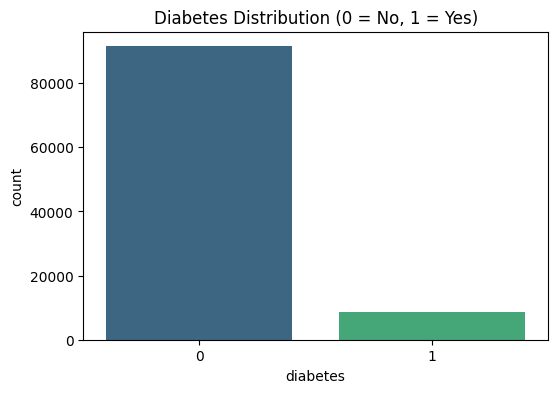

In [ ]:
plt.figure(figsize=(6, 4)) # Set the size of graph
sns.countplot(x='diabetes', data=df, palette='viridis') # Create a bar chart for the diabetes column
plt.title('Diabetes Distribution (0 = No, 1 = Yes)') # Add a title
plt.show() # Display t

***Key-Insight***

"This chart shows how many people in our data
have diabetes versus those who do not. We can see that the data is imbalanced, meaning there are many more non-diabetic people than diabetic ones."

***Correlation Heatmap (Feature Relationships)***

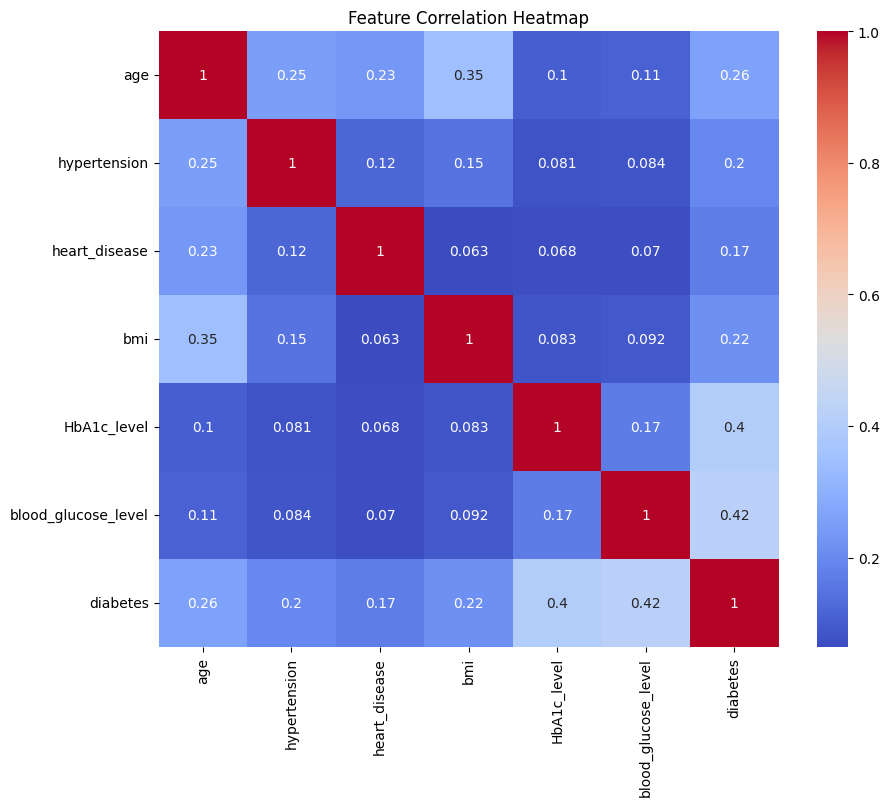

In [ ]:
plt.figure(figsize=(10, 8)) # Set a  size
numeric_df = df.select_dtypes(include=['number']) # Keep only columns with numbers
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm') # Draw a colored map of relationships
plt.title('Feature Correlation Heatmap') # Title the heatmap
plt.show() # Display

***Key-Insight***

"Blood Glucose and HbA1c levels have the strongest connection to diabetes. Age and BMI are also important but less than medical test results."

***Scatter Plot (Visual Insights)***

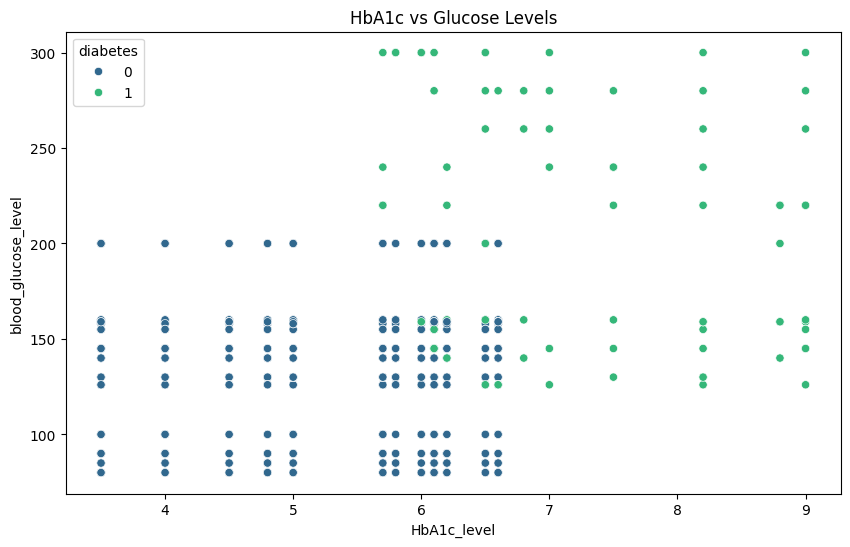

In [ ]:
plt.figure(figsize=(10, 6)) # Set the size
sns.scatterplot(x='HbA1c_level', y='blood_glucose_level', hue='diabetes', data=df.sample(1000),palette='viridis') # Plot points colored by diabetes column
plt.title('HbA1c vs Glucose Levels') # Add a title
plt.show() # display

***Key-Insight***

"When looking at Glucose and HbA1c together, there is a clear 'Danger Zone' at the top right of the graph. People in this area are almost always diabetic."

***Box Plots (Outlier Detection)***

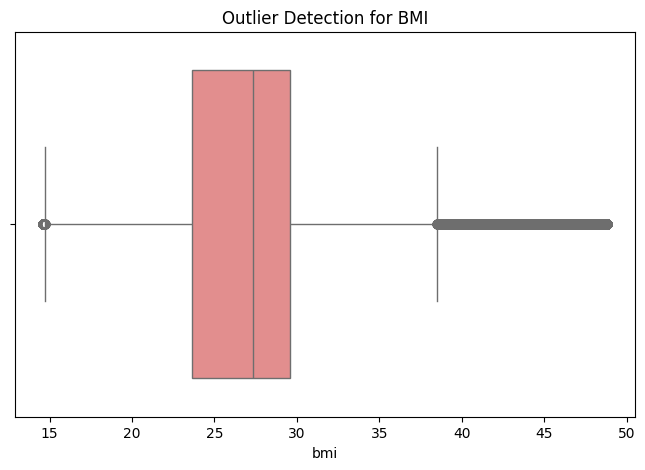

In [ ]:
plt.figure(figsize=(8, 5)) # Create a size
sns.boxplot(x='bmi', data=df, color='lightcoral') # Draw a box plot to find outliers in BMI
plt.title('Outlier Detection for BMI') # Set the heading
plt.show() # Display

***Key-Insight***

"This Box Plot shows that there are no points outside the whiskers. We used Winsorization to cap the outliers. This means we moved extreme values (like very high BMI or Glucose) to the maximum allowed limit instead of deleting them. This keeps our data complete while preventing extreme numbers from confusing the model."

***Histograms (Variable Distribution)***

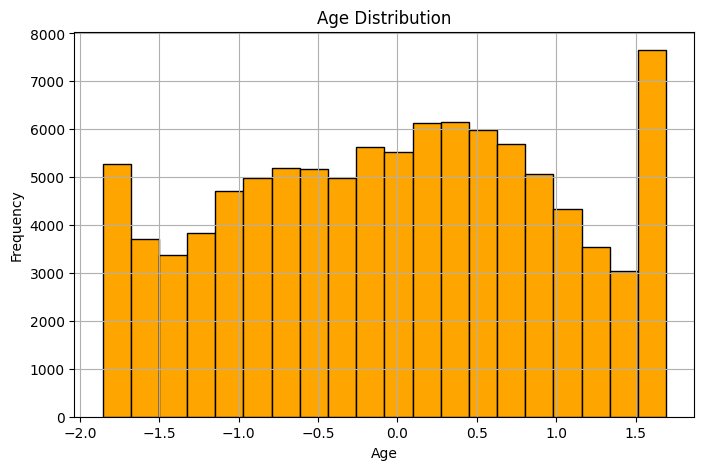

In [ ]:
plt.figure(figsize=(8, 5)) # Set the size
df['age'].hist(bins=20, color='orange',edgecolor='black') # Create a histogram for age with 20 bars
plt.title('Age Distribution') # Give the title
plt.xlabel('Age') # Label the horizontal axis as Age
plt.ylabel('Frequency') # Label the vertical axis as Count
plt.show() # Output

***Key-Insight***

"Age is distributed evenly, but Glucose and HbA1c show distinct peaks. Healthy people are grouped at lower levels, while diabetic patients create a second peak at higher values."